# Equivariant Filter (EqF) in CasADi

This notebook is a compact walkthrough for defining EqF problems with cyecca and CasADi.  The reusable derivation engine lives in `equivariant_filter_casadi.py`, while the longer problem-specific implementations live in `bearing_eqf_problem.py` and `attitude_iekf_problem.py`.

The main pattern is:

1. choose a cyecca Lie group,
2. define the state, input, output, lift, action, and chart maps,
3. build an `EqFProblem`,
4. call `derive_equivariant_filter(problem)`.



## Generic EqF Derivation Engine

The core API is `EqFProblem` plus `derive_equivariant_filter(problem)`.  A problem supplies the geometry: cyecca `lie_group`, state action `phi`, input action `psi`, optional output action `rho`, lift `Lambda`, origin, chart inverse, and the embedding of local error coordinates into the Lie algebra.  CasADi then differentiates those maps to produce `A`, `B`, `C`, `C*`, and `yhat`.

The API does not require SO(3).  The translation example below is deliberately small so the problem-definition pattern is easy to copy.



In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import casadi as ca
import cyecca.lie as lie
import numpy as np


def add_example_module_path():
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([base, base / "examples"])
    for candidate in candidates:
        if (candidate / "equivariant_filter_casadi.py").exists():
            sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError("Could not find equivariant_filter_casadi.py from the kernel working directory")


module_path = add_example_module_path()
print(f"Using EqF modules from {module_path}")

from equivariant_filter_casadi import EqFProblem, derive_equivariant_filter


def casadi_value(x):
    return next(iter(x.values())) if isinstance(x, dict) else x



Using EqF modules from c:\Users\Yahor\OneDrive - purdue.edu\Courses\4th Year\AAE 590 LGM\AAE-590-LGM\Project\eqf


In [2]:
# Longer paper-specific examples are imported from problem modules so this
# notebook can stay focused on the EqF problem-definition workflow.
from attitude_iekf_problem import (
    make_attitude_iekf_symbolics,
    plot_iekf_history,
    simulate_attitude_iekf,
)
from bearing_eqf_problem import (
    make_bearing_eqf_symbolics,
    measurement_linearization_error_grid,
    plot_bearing_history,
    plot_bearing_monte_carlo,
    plot_measurement_linearization_errors,
    plot_official_auto_eqf_history,
    simulate_bearing_monte_carlo,
    simulate_bearing_only_eqf,
    simulate_official_auto_eqf_sphere_example,
)
from so3_example_utils import exp_so3_np, hat_np, normalize_np



## Minimal cyecca Problem Definition

Before using the SO(3)-based paper examples, here is the same API on the cyecca translation group `R2`.  The state space is also `R2`, the action is `phi(g, x) = x + g`, the dynamics are `x_dot = u`, and the output is `y = x`.

This cell is meant to be the copyable template for defining a new EqF problem: only the group and the geometric maps change.



In [3]:
g_trans = ca.SX.sym("g_trans", 2)
x_trans = ca.SX.sym("x_trans", 2)
u_trans = ca.SX.sym("u_trans", 2)
eps_trans = ca.SX.sym("eps_trans", 2)
y_trans = ca.SX.sym("y_trans", 2)

translation_problem = EqFProblem(
    name="notebook_translation",
    state=x_trans,
    group=g_trans,
    input=u_trans,
    error=eps_trans,
    output_measurement=y_trans,
    lie_group=lie.R2,
    origin=ca.SX([0.0, 0.0]),
    parameters=(),
    action=lambda g, x: x + g,
    input_action=lambda g, u: u,
    output=lambda x: x,
    output_action=lambda g, y: y + g,
    lift=lambda x, u: u,
    chart_inv=lambda eps: eps,
    algebra_from_error=lambda eps: eps,
)

translation_derived = derive_equivariant_filter(translation_problem)
print("A =", np.array(translation_derived.A([0.0, 0.0], [0.0, 0.0]), dtype=float))
print("B =", np.array(translation_derived.B([0.0, 0.0], [0.0, 0.0]), dtype=float))
print("C =", np.array(translation_derived.C([0.0, 0.0]), dtype=float))
print("C* =", np.array(translation_derived.C_star([0.0, 0.0], [0.2, -0.1]), dtype=float))


A = [[0. 0.]
 [0. 0.]]
B = [[1. 0.]
 [0. 1.]]
C = [[1. 0.]
 [0. 1.]]
C* = [[1. 0.]
 [0. 1.]]


## Bearing-Only EqF Matrices

The paper's single-bearing SO(3) problem is defined in `bearing_eqf_problem.py`.  The notebook calls the helper here so readers can inspect the derived matrices without carrying all of the simulation and plotting code inline.



In [4]:
bearing_helpers = make_bearing_eqf_symbolics()

Rhat_num = np.eye(3)
Omega_num = np.zeros(3)
y_num = np.array([0.8, -0.2, 0.1])
c_m_num = 1.0

print("A =\n", np.array(bearing_helpers.A(Rhat_num, Omega_num, c_m_num), dtype=float))
print("B(I) =\n", np.array(bearing_helpers.B(Rhat_num, Omega_num, c_m_num), dtype=float))
print("C(I) =\n", np.array(bearing_helpers.C(Rhat_num, c_m_num), dtype=float))
print("C*(I, y) =\n", np.array(bearing_helpers.C_star(Rhat_num, y_num, c_m_num), dtype=float))



A =
 [[0. 0.]
 [0. 0.]]
B(I) =
 [[0. 1. 0.]
 [0. 0. 1.]]
C(I) =
 [[ 0. -0.]
 [ 0. -1.]
 [ 1. -0.]]
C*(I, y) =
 [[-0.05 -0.1 ]
 [ 0.   -0.9 ]
 [ 0.9   0.  ]]


The next cell is a small regression test: it compares the generic AD-derived matrices against the closed forms printed in the paper for the two worked examples.  These formulas are used only as tests, not to build the matrices.

In [5]:
bearing = make_bearing_eqf_symbolics()
R = exp_so3_np(np.array([0.2, -0.3, 0.4]))
omega = np.array([0.1, -0.2, 0.3])
y = np.array([0.8, -0.2, 0.1])
c_m = 1.0
e1 = np.array([1.0, 0.0, 0.0])
P_m = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
selector = np.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
yhat = c_m * (R.T @ e1)

iekf = make_attitude_iekf_symbolics()
r1 = np.array([0.0, 0.0, 1.0])
r2 = normalize_np(np.array([0.3, 0.9, 0.1]))
Rhat = exp_so3_np(np.array([-0.1, 0.2, 0.3]))
C_iekf_expected = np.vstack((Rhat.T @ hat_np(r1), Rhat.T @ hat_np(r2)))

derivation_residuals = {
    "bearing_A": float(np.max(np.abs(np.array(bearing.A(R, omega, c_m), dtype=float)))),
    "bearing_B": float(
        np.max(np.abs(np.array(bearing.B(R, omega, c_m), dtype=float) - selector @ R))
    ),
    "bearing_C": float(
        np.max(np.abs(np.array(bearing.C(R, c_m), dtype=float) - hat_np(yhat) @ R.T @ P_m))
    ),
    "bearing_C_star": float(
        np.max(
            np.abs(
                np.array(bearing.C_star(R, y, c_m), dtype=float)
                - 0.5 * (hat_np(y) + hat_np(yhat)) @ R.T @ P_m
            )
        )
    ),
    "iekf_A": float(np.max(np.abs(np.array(iekf.A(Rhat, omega, r1, r2), dtype=float)))),
    "iekf_C": float(
        np.max(np.abs(np.array(iekf.C(Rhat, r1, r2), dtype=float) - C_iekf_expected))
    ),
}

derivation_residuals


{'bearing_A': 0.0,
 'bearing_B': 0.0,
 'bearing_C': 1.1102230246251565e-16,
 'bearing_C_star': 1.1102230246251565e-16,
 'iekf_A': 0.0,
 'iekf_C': 2.7755575615628914e-17}

The output-equivariant matrix reduces the residual approximation error from second order to third order in the normal-coordinate error.  This quick numerical check evaluates the residual error for a few perturbation sizes.

In [6]:
# The reusable helper below exposes the same derived bearing problem plus
# the normal-coordinate and embedded-EKF utilities used for plotting.
bearing_helpers = make_bearing_eqf_symbolics()

for scale in [1e-1, 5e-2, 1e-2]:
    eps = np.array([scale, -0.7 * scale])
    err = np.array(bearing_helpers.output_linearization_error(eps, 1.0), dtype=float)
    print(
        f"||eps||={np.linalg.norm(eps):.3e}: "
        f"EqF error={np.linalg.norm(err[:, 0]):.3e}, "
        f"EqF* error={np.linalg.norm(err[:, 1]):.3e}"
    )


||eps||=1.221e-01: EqF error=7.447e-03, EqF* error=1.515e-04
||eps||=6.103e-02: EqF error=1.862e-03, EqF* error=1.894e-05
||eps||=1.221e-02: EqF error=7.450e-05, EqF* error=1.516e-07


## Measurement Linearization Error Plot

The paper's Fig. 3 compares the measurement residual linearization error over the sphere.  The plot below uses the same standard spherical coordinates, `eta = [sin(theta) cos(phi), sin(theta) sin(phi), cos(theta)]`, so the linearization point `e1` appears at `(phi, theta) = (0, pi/2)`.  There appears to be a sign inconsistency in the paper's EKF heatmap: the text says the EKF coordinates are `vartheta(eta) := eta - e1`, but the plotted EKF panel matches the opposite sign.  The main plot here uses the text-consistent EKF residual; the paper-style opposite-sign convention is computed below only as a reproduction check.  The EqF and EqF* panels use the normal coordinates from the equivariant construction.  The printed `Secant` diagnostic is a measurement-dependent exact residual fit, included to show that one can do better than the paper's averaged EqF* output matrix if the update is allowed to depend more directly on the current measurement.  The plotted EKF/EqF/EqF* panels share one color scale.


text-consistent residual linearization error ranges
EKF: min=0.000000, max=2.000000
EqF: min=0.000000, max=3.724192
EqF*: min=0.000000, max=2.000000
Secant: min=0.000000, max=0.000000
shared color scale: vmin=0.000000, vmax= 3.724191776550046
paper-style opposite-sign EKF max: 2.309401076591077


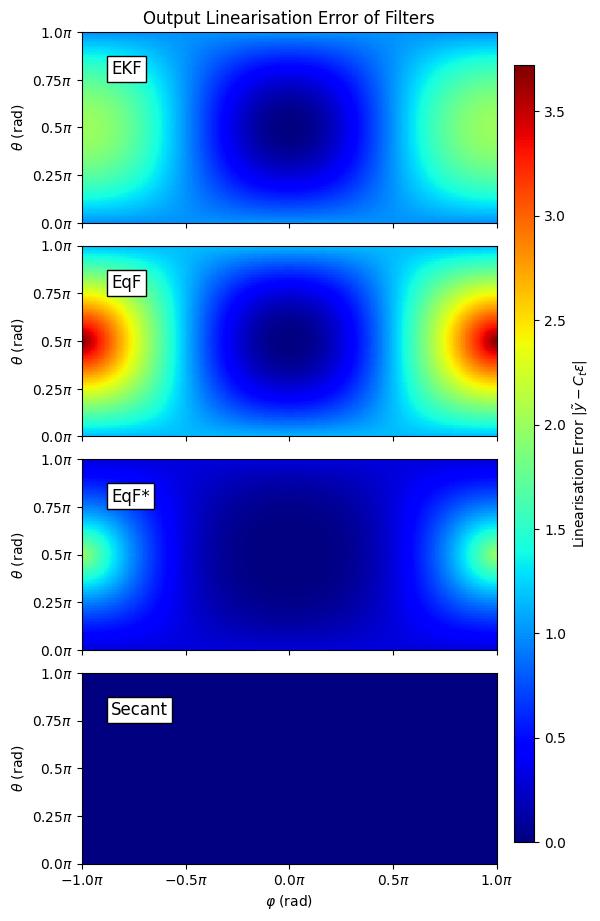

In [7]:
measurement_grid = measurement_linearization_error_grid(n_polar=121, n_azimuth=241, ekf_convention="text", include_secant=True)
paper_style_measurement_grid = measurement_linearization_error_grid(n_polar=121, n_azimuth=241, ekf_convention="paper")
plot_measurement_linearization_errors(measurement_grid)

print("text-consistent residual linearization error ranges")
for name in ["EKF", "EqF", "EqF*", "Secant"]:
    print(f"{name}: min={measurement_grid[name].min():.6f}, max={measurement_grid[name].max():.6f}")
print("shared color scale: vmin=0.000000, vmax=", max(float(measurement_grid[name].max()) for name in ["EKF", "EqF", "EqF*"]))
print("paper-style opposite-sign EKF max:", paper_style_measurement_grid["EKF"].max())


## Bearing-Only Simulation

This follows the paper's Section VII setup where the paper is explicit: the angular velocity profile from Eq. (50), the initial condition/noise distributions from Eq. (50), the embedded-coordinate EKF with the virtual norm constraint, and the EqF/EqF* observers on SO(3).  The lower panels plot the Lyapunov value `epsilon.T @ Sigma^{-1} @ epsilon` from Eq. (39).  The paper says the EqF gains use the Section VI-A tuning procedure but does not publish the numerical `M_epsilon` and `N_epsilon` values used in Figs. 1-2, so those values remain exposed here.  The default cells below use the paper's broad initial covariance and a conservative output-linearization covariance; changing those tuning values can change the apparent EKF/EqF ordering.


Noise-free final errors [deg]
EqF:   0.06074609065896909
EqF*:  0.04473355459046759
EKF:   0.04606697986441928
Noise-free final Lyapunov values
EqF:   4.771277889386319e-05
EqF*:  2.586807981502696e-05
EKF:   5.672312637137114e-05


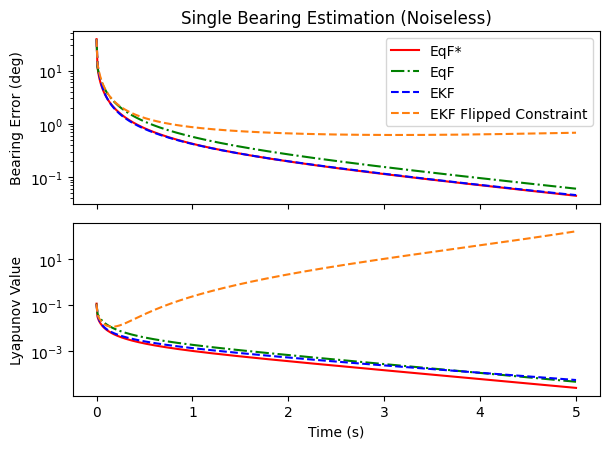

In [8]:
bearing_noise_free = simulate_bearing_only_eqf(
    seed=7,
    sigma_omega=0.0,
    sigma_y=0.0,
    filter_sigma_omega=0.01,
    filter_sigma_y=0.05,
    m_epsilon=1e-2,
    n_epsilon=5e-2,
)
plot_bearing_history(bearing_noise_free, include_secant=False)

print("Noise-free final errors [deg]")
print("EqF:  ", bearing_noise_free["eqf_err_deg"][-1])
print("EqF*: ", bearing_noise_free["eqf_star_err_deg"][-1])
print("EKF:  ", bearing_noise_free["ekf_err_deg"][-1])
print("Noise-free final Lyapunov values")
print("EqF:  ", bearing_noise_free["eqf_lyapunov"][-1])
print("EqF*: ", bearing_noise_free["eqf_star_lyapunov"][-1])
print("EKF:  ", bearing_noise_free["ekf_lyapunov"][-1])


c:\Users\Yahor\OneDrive - purdue.edu\Courses\4th Year\AAE 590 LGM\AAE-590-LGM\Project\.venv\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


Noisy Monte Carlo final median errors [deg]
EqF:   0.34949782658742645
EqF*:  0.2500111975614481
EKF:   0.2528770688845842
Noisy Monte Carlo final median Lyapunov values
EqF:   0.0015984681563887063
EqF*:  0.0008080033260565609
EKF:   0.001286998254864636


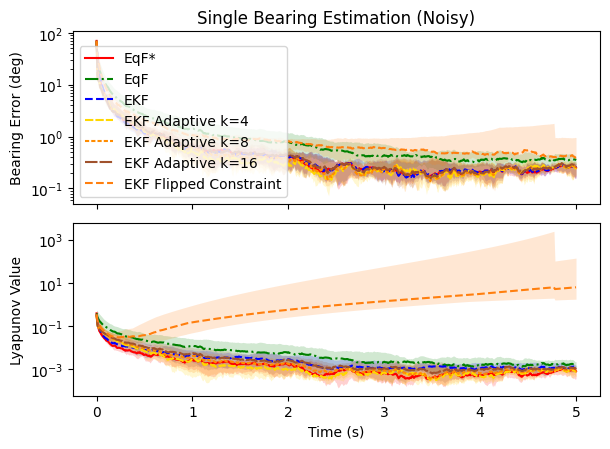

In [9]:
# Paper Fig. 2 uses 500 noisy Monte Carlo trials. The notebook default is
# intentionally smaller so rerunning all cells stays quick; set n_trials=500
# here when regenerating the full paper-scale figure. The EKF and EqF use
# the same measurement-noise covariance by default; changing EKF-only
# covariance is a tuning experiment, not an apples-to-apples comparison.
bearing_monte_carlo = simulate_bearing_monte_carlo(
    n_trials=10,
    parallel=True,
    n_jobs=-1,
    sigma_omega=0.01,
    sigma_y=0.05,
    filter_sigma_omega=0.01,
    filter_sigma_y=0.05,
    m_epsilon=1e-2,
    n_epsilon=5e-2,
)
plot_bearing_monte_carlo(bearing_monte_carlo, include_secant=False)

print("Noisy Monte Carlo final median errors [deg]")
print("EqF:  ", bearing_monte_carlo["eqf_err_deg_median"][-1])
print("EqF*: ", bearing_monte_carlo["eqf_star_err_deg_median"][-1])
print("EKF:  ", bearing_monte_carlo["ekf_err_deg_median"][-1])
print("Noisy Monte Carlo final median Lyapunov values")
print("EqF:  ", bearing_monte_carlo["eqf_lyapunov_median"][-1])
print("EqF*: ", bearing_monte_carlo["eqf_star_lyapunov_median"][-1])
print("EKF:  ", bearing_monte_carlo["ekf_lyapunov_median"][-1])


## Official auto_eqf Source Reproduction

The public source linked from the paper is `STR-ANU/auto_eqf`.  It contains `sphere_example.py`, a single automatic EqF example for the sphere.  It does not contain the EKF/EqF/EqF* Monte Carlo comparison script used to produce the TAC paper figures.  The cell below mirrors the public example parameters directly: `seed=0`, `init_noise=0.5`, `gyr_noise=0.01`, `meas_noise=0.05`, `dt=0.01`, `apply_gm_noise=True`, and angular velocity `[0.1 cos(2t), 0.2 sin(t), 0]`.


Official source-style final error [deg] 0.3608987097806037
Official source-style final Lyapunov 0.7974898139642638


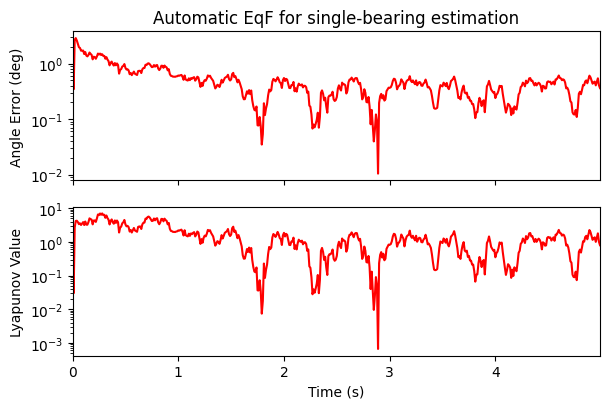

In [10]:
official_auto_eqf = simulate_official_auto_eqf_sphere_example()
plot_official_auto_eqf_history(official_auto_eqf)

print("Official source-style final error [deg]", official_auto_eqf["err_deg"][-1])
print("Official source-style final Lyapunov", official_auto_eqf["lyapunov"][-1])


## IEKF as a Special Case of the EqF

The attitude IEKF/torsor problem definition is in `attitude_iekf_problem.py`.  This keeps the notebook centered on usage while leaving the detailed SO(3) setup available as regular Python source.



In [11]:
iekf_helpers = make_attitude_iekf_symbolics()

Rhat_num = np.eye(3)
Omega_num = np.zeros(3)
r1_num = np.array([0.0, 0.0, 1.0])
r2_num = np.array([0.3, 0.9, 0.1])

print("IEKF A =\n", np.array(iekf_helpers.A(Rhat_num, Omega_num, r1_num, r2_num), dtype=float))
print("IEKF C(I) =\n", np.array(iekf_helpers.C(Rhat_num, r1_num, r2_num), dtype=float))



IEKF A =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
IEKF C(I) =
 [[ 0.  -1.   0. ]
 [ 1.   0.   0. ]
 [ 0.   0.   0. ]
 [ 0.  -0.1  0.9]
 [ 0.1  0.  -0.3]
 [-0.9  0.3  0. ]]


IEKF final SO(3) error [deg] 0.5892129839641068


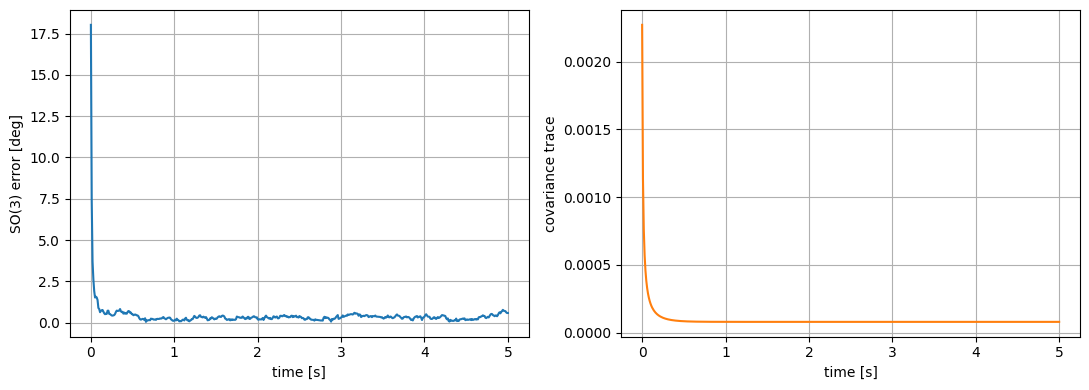

In [12]:
iekf_hist = simulate_attitude_iekf(sigma_omega=0.01, sigma_y=0.03)
plot_iekf_history(iekf_hist)

print("IEKF final SO(3) error [deg]", iekf_hist["err_deg"][-1])

In [13]:
if "bearing_monte_carlo" not in globals():
    bearing_monte_carlo = simulate_bearing_monte_carlo(
        n_trials=10,
        sigma_omega=0.01,
        sigma_y=0.05,
        parallel=True,
        n_jobs=-1,
        m_epsilon=1e-2,
        n_epsilon=5e-2,
    )
if "iekf_hist" not in globals():
    iekf_hist = simulate_attitude_iekf(sigma_omega=0.01, sigma_y=0.03)

{
    "bearing_EqF_final_median_deg": float(bearing_monte_carlo["eqf_err_deg_median"][-1]),
    "bearing_EqF_star_final_median_deg": float(bearing_monte_carlo["eqf_star_err_deg_median"][-1]),
    "bearing_EKF_final_median_deg": float(bearing_monte_carlo["ekf_err_deg_median"][-1]),
    "iekf_final_deg": float(iekf_hist["err_deg"][-1]),
}


{'bearing_EqF_final_median_deg': 0.34949782658742645,
 'bearing_EqF_star_final_median_deg': 0.2500111975614481,
 'bearing_EKF_final_median_deg': 0.2528770688845842,
 'iekf_final_deg': 0.5892129839641068}